In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'
NBINS      = 35
MINSAMPLES = 50
REGISTRY   = {row['name']:dict(form=row['form'],constants=json.loads(row['constants']),train_loss=row['train_loss'],valid_loss=row['valid_loss'])
              for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [4]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def calc_moisture_term(rh):
    return kappa*(rh-rh0)

def calc_instability_term(thetae,thetaestar):
    return thetae-gamma*thetaestar-theta0

def predict_from_sr_atm(moisture,instability):
    return np.maximum(np.expm1(eta*np.maximum(moisture,instability)**3),0.0)

def bin_2d(x,y,z,edges,minsamples=MINSAMPLES):
    xi     = np.clip(np.digitize(x,edges[0])-1,0,len(edges[0])-2)
    yi     = np.clip(np.digitize(y,edges[1])-1,0,len(edges[1])-2)
    shape  = (len(edges[0])-1,len(edges[1])-1)
    counts = np.zeros(shape)
    sums   = np.zeros(shape)
    np.add.at(counts,(xi,yi),1)
    np.add.at(sums,(xi,yi),z)
    return np.where(counts>=minsamples,sums/np.maximum(counts,1),np.nan)

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
c3,c4,c5 = (REGISTRY['sr_atm_eq']['constants'][name] for name in ['c3','c4','c5'])

eta    = STATS['tp_std']*c3/STATS['thetae_std']**3
gamma  = c4*STATS['thetae_std']/STATS['thetaestar_std']
theta0 = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+c5*STATS['thetae_std']
kappa  = STATS['thetae_std']/STATS['rh_std']
rh0    = STATS['rh_mean']

constdf = pd.DataFrame([
    {'Constant':'$\\eta$','Value':f'{eta:.3e}','Units':'1/K³'},
    {'Constant':'$\\gamma$','Value':f'{gamma:.3f}','Units':'dimensionless'},
    {'Constant':'$\\Theta_0$','Value':f'{theta0:.2f}','Units':'K'},
    {'Constant':'$\\kappa$','Value':f'{kappa:.3f}','Units':'K/%'},
    {'Constant':'$\\mathrm{RH}_0$','Value':f'{rh0:.2f}','Units':'%'}])
display(constdf.style.hide(axis='index'))

Constant,Value,Units
$\eta$,1.106e-03,1/K³
$\gamma$,1.058,dimensionless
$\Theta_0$,-30.45,K
$\kappa$,0.414,K/%
$\mathrm{RH}_0$,68.07,%


In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = (ds.sizes[dim] for dim in ['time','lat','lon'])
    lat,lon,dsig    = ds['lat'].values,ds['lon'].values,ds['dsig'].values
    fields = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp     = ds['tp'].transpose('time','lat','lon').values.ravel()
with xr.open_dataset(os.path.join(PREDSDIR,f'sr_atm_eq_{SPLIT}_predictions.nc')) as ds:
    savedtp = ds['tp'].squeeze().transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals   = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
moisture    = calc_moisture_term(integrals['rh'])
instability = calc_instability_term(integrals['thetae'],integrals['thetaestar'])
predtp      = predict_from_sr_atm(moisture,instability)
finite      = np.isfinite(moisture)&np.isfinite(instability)&np.isfinite(tp)
print(f'Max difference from saved SR-ATM predictions: {np.nanmax(np.abs(predtp[finite]-savedtp[finite])):.2e} mm')

fracmap  = np.nanmean(np.where(finite,moisture>=instability,np.nan).reshape(ntime,nlat,nlon),axis=0)
mlim     = tuple(np.percentile(moisture[finite],[1,99]))
ilim     = tuple(np.percentile(instability[finite],[1,99]))
diagonal = [min(mlim[0],ilim[0]),max(mlim[1],ilim[1])]
edges    = (np.linspace(*mlim,NBINS+1),np.linspace(*ilim,NBINS+1))
centers  = [0.5*(edge[:-1]+edge[1:]) for edge in edges]
tpbinned = bin_2d(moisture[finite],instability[finite],tp[finite],edges)
density  = np.log10(np.histogram2d(moisture[finite],instability[finite],bins=edges)[0].clip(1))
mgrid,igrid = np.linspace(*mlim,200),np.linspace(*ilim,200)
predgrid    = predict_from_sr_atm(*np.meshgrid(mgrid,igrid))

Max difference from saved SR-ATM predictions: 8.53e-02 mm


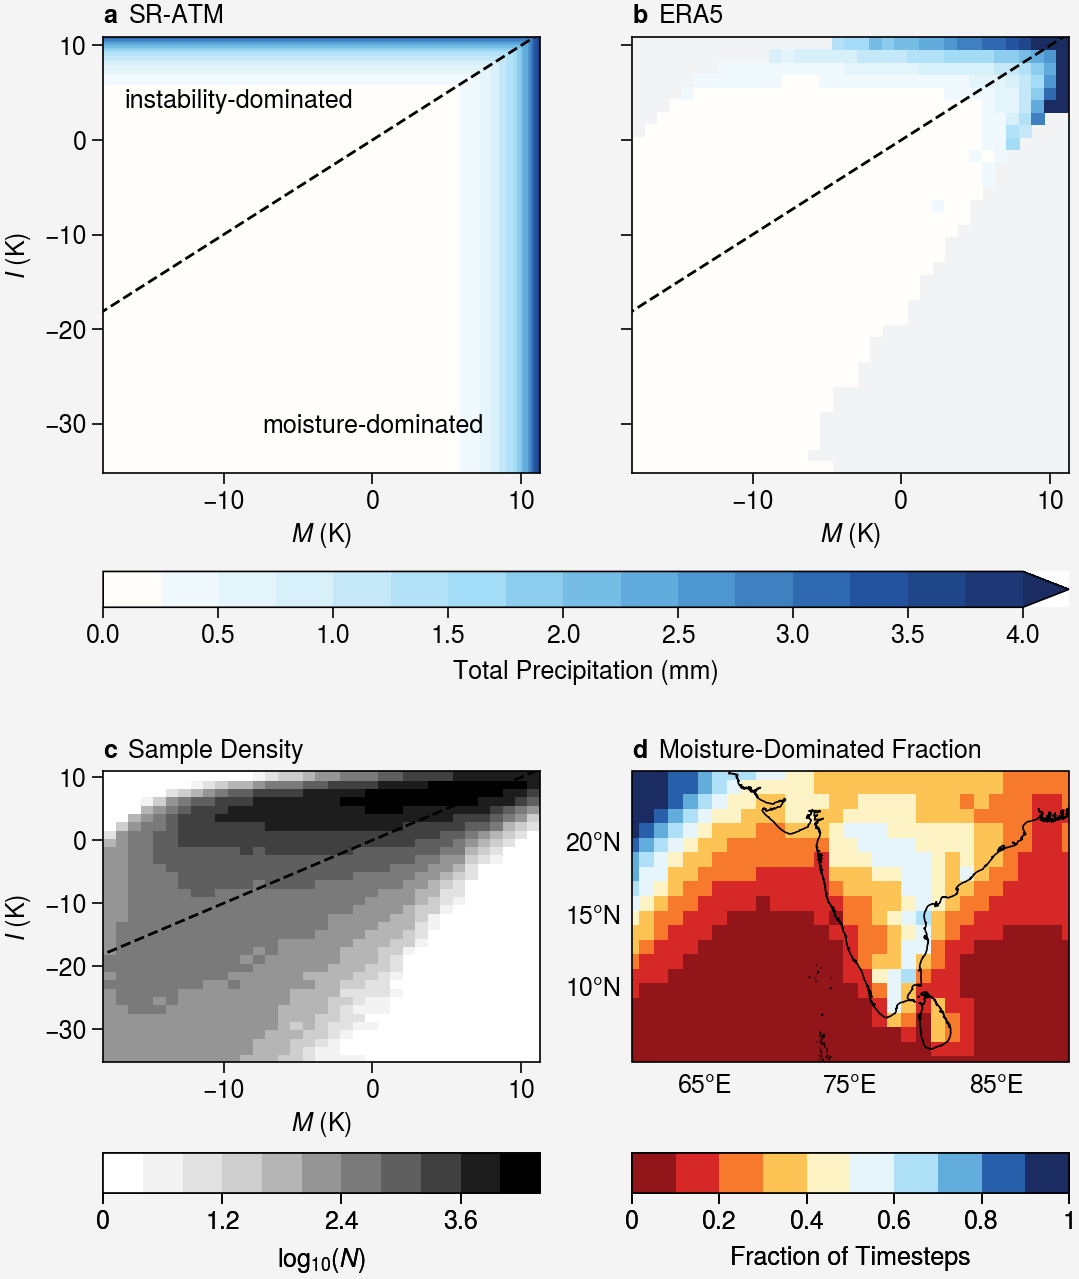

In [11]:
xlabel   = '$\\mathit{M}$ (K)'
ylabel   = '$\\mathit{I}$ (K)'
kwprecip = dict(cmap='ColdHot_r',cmap_kw={'left':0.5},vmin=0,vmax=4,levels=18,extend='max')
kwmap    = dict(coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',
                latlim=LATRANGE,latlines=[10,15,20],latlabels='l',grid=False)

fig,axs = pplt.subplots([[1,2],[3,4]],figwidth=5.5,proj={4:'cyl'},share=False,hspace=9)
axs[2].set_box_aspect((LATRANGE[1]-LATRANGE[0])/(LONRANGE[1]-LONRANGE[0]))
m0 = axs[0].pcolormesh(mgrid,igrid,predgrid,**kwprecip)
axs[1].pcolormesh(*centers,tpbinned.T,**kwprecip)
m2 = axs[2].pcolormesh(*centers,density.T,cmap='Grays',vmin=0)
m3 = axs[3].pcolormesh(lon,lat,fracmap,cmap='ColdHot_r',vmin=0,vmax=1)
for ax in axs[:3]:
    ax.plot(diagonal,diagonal,'k--',lw=1)
axs[0].text(mlim[1]-0.13*(mlim[1]-mlim[0]),ilim[0]+0.08*(ilim[1]-ilim[0]),'moisture-dominated',ha='right',va='bottom')
axs[0].text(mlim[0]+0.05*(mlim[1]-mlim[0]),ilim[1]-0.12*(ilim[1]-ilim[0]),'instability-dominated',ha='left',va='top')
axs[:3].format(xlabel=xlabel,xlabelpad=2,xlim=mlim,ylim=ilim)
axs[0].format(title='SR-ATM',ylabel=ylabel)
axs[1].format(title='ERA5',yticklabels=[],facecolor='gray1')
axs[2].format(title='Sample Density',ylabel=ylabel)
axs[3].format(title='Moisture-Dominated Fraction',**kwmap)
axs[2].colorbar(m2,loc='b',label='log$_{10}$($\\mathit{N}$)')
axs[3].colorbar(m3,loc='b',ticks=0.2,label='Fraction of Timesteps')
fig.format(abc=True,titleloc='l')

fig.canvas.draw()
top    = [ax.get_position() for ax in axs[:2]]
bottom = [ax.get_position() for ax in axs[2:]]
middle = 0.5*(min(pos.y0 for pos in top)+max(pos.y1 for pos in bottom))
cax = fig.add_axes([top[0].x0,middle-0.09/fig.get_figheight()+0.15/fig.get_figheight(),top[1].x1-top[0].x0,0.18/fig.get_figheight()])
fig.colorbar(m0,cax=cax,orientation='horizontal',label='Total Precipitation (mm)',extend='max')
pplt.show()
fig.save('../figs/fig_4.jpg')